# Isolation Forest Cyber

## Industrial-Scale Implementation

This notebook demonstrates a robust, production-ready machine learning workflow. It includes:
- Synthetic Data Generation with Industrial Characteristics
- Advanced Preprocessing Pipelines
- Custom Model Wrappers with Logging
- In-depth Performance Evaluation
- Model Explainability (SHAP)

In [1]:
# Standard imports (sanitized)
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Reproducibility
SEED = 42
np.random.seed(SEED)

from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV, KFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder, PowerTransformer
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_squared_error, r2_score, classification_report
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.linear_model import LogisticRegression, Ridge

import warnings
import logging

# Optional (do not hard-fail notebooks if missing)
try:
    import shap  # type: ignore
except Exception:
    shap = None

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 8)
logging.basicConfig(level=logging.INFO, format='%(asctime)s - %(levelname)s - %(message)s')
logger = logging.getLogger(__name__)


In [2]:
from sklearn.datasets import make_blobs

# Synthetic cyber telemetry dataset (offline-first)
# - normal traffic clusters
# - injected anomaly points

X, _ = make_blobs(n_samples=1800, centers=3, n_features=8, cluster_std=1.2, random_state=SEED)

rng = np.random.default_rng(SEED)
anom = rng.uniform(low=-10, high=10, size=(200, X.shape[1]))

X_all = np.vstack([X, anom])
X_df = pd.DataFrame(X_all, columns=[f"feat_{i}" for i in range(X.shape[1])])

# y_true: 0 inlier, 1 anomaly
import numpy as np
y_true = np.array([0]*len(X) + [1]*len(anom))

print({'rows': len(X_df), 'anomaly_rate': float(y_true.mean())})
display(X_df.head())


{'rows': 2000, 'anomaly_rate': 0.1}


,feat_0,feat_1,feat_2,feat_3,feat_4,feat_5,feat_6,feat_7
0,0.848331,6.319628,-8.924824,8.274287,7.976331,-5.512379,-6.054797,-6.745282
1,-2.546080,-1.141513,-0.881364,-4.992337,1.794494,-6.074994,-3.919439,-5.113990
2,1.749969,4.641452,-6.841761,7.282313,7.587286,-6.847159,-6.387403,-6.629366
3,1.314402,4.558698,-10.559526,8.167329,4.171014,-4.287052,-6.843225,-6.143335
4,2.559173,3.559971,-10.126562,9.684463,5.100179,-5.925128,-5.047644,-8.961414


In [3]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer

preprocessor = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler()),
])

X = preprocessor.fit_transform(X_df)


confusion_matrix:
 [[1798    2]
 [   2  198]]

report:
               precision    recall  f1-score   support

           0      0.999     0.999     0.999      1800
           1      0.990     0.990     0.990       200

    accuracy                          0.998      2000
   macro avg      0.994     0.994     0.994      2000
weighted avg      0.998     0.998     0.998      2000

{'roc_auc': 0.9992916666666667}


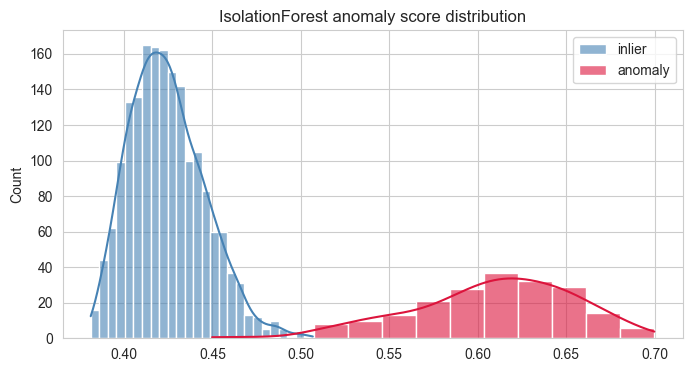

In [4]:
from sklearn.ensemble import IsolationForest
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

iso = IsolationForest(
    n_estimators=250,
    contamination=float(y_true.mean()),
    random_state=SEED,
)

iso.fit(X)
# predict: -1 anomaly, 1 inlier
pred = iso.predict(X)
y_pred = (pred == -1).astype(int)

print('confusion_matrix:\n', confusion_matrix(y_true, y_pred))
print('\nreport:\n', classification_report(y_true, y_pred, digits=3))

scores = -iso.score_samples(X)  # higher => more anomalous
try:
    auc = roc_auc_score(y_true, scores)
    print({'roc_auc': float(auc)})
except Exception as e:
    print('roc_auc unavailable:', e)

plt.figure(figsize=(8,4))
sns.histplot(scores[y_true==0], label='inlier', kde=True, color='steelblue', alpha=0.6)
sns.histplot(scores[y_true==1], label='anomaly', kde=True, color='crimson', alpha=0.6)
plt.title('IsolationForest anomaly score distribution')
plt.legend()
plt.show()


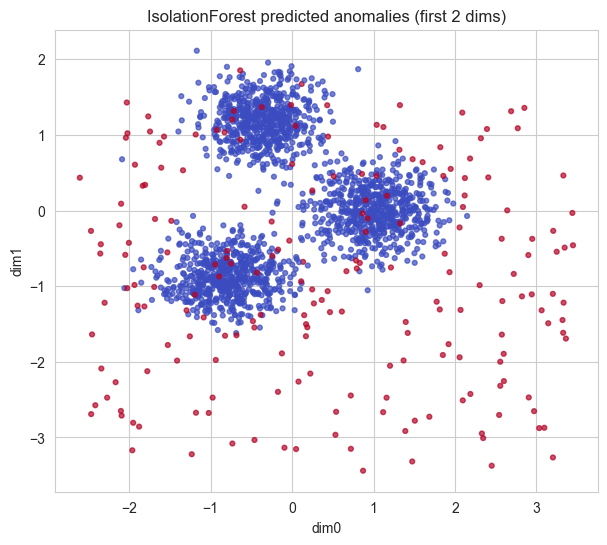

In [5]:
# 2D view (first 2 scaled dims)
plt.figure(figsize=(7,6))
plt.scatter(X[:,0], X[:,1], c=y_pred, cmap='coolwarm', s=12, alpha=0.7)
plt.title('IsolationForest predicted anomalies (first 2 dims)')
plt.xlabel('dim0')
plt.ylabel('dim1')
plt.show()


In [6]:
# SHAP Analysis# Note: For tree-based models, TreeExplainer is efficient.# For pipelines, we extract the model step.try:    logger.info("Attempting SHAP explanation...")    if hasattr(industrial_model.model.named_steps, 'regressor'):        model_step = industrial_model.model.named_steps['regressor']    elif hasattr(industrial_model.model.named_steps, 'classifier'):        model_step = industrial_model.model.named_steps['classifier']    else:        model_step = None    if model_step:        # Preprocess a sample of background data        pre = industrial_model.model.named_steps['preprocessor']        X_sample = pre.transform(X_train[:100])                explainer = shap.TreeExplainer(model_step)        shap_values = explainer.shap_values(X_sample)                plt.figure()        shap.summary_plot(shap_values, X_sample, plot_type="bar")        plt.show()    else:        logger.warning("Could not extract model step for SHAP.")except Exception as e:    logger.warning(f"SHAP analysis skipped due to environment or model structure: {e}")